<a href="https://colab.research.google.com/github/cacjr/ML-Prototipo-De-Monitoramento-Inteligente/blob/main/Checkpoint5_ML_SafeForge_ErrorExit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Checkpoint 5 — Machine Learning & Modelling  
## SafeForge Industrial Risk Advanced

Alunos:

Claudio Alves

Sarah Furlan

Rodrigo Wolkoff

Luna Rousseau

Mario Antonio

Vinicius Augusto

Turma: 1TIAPR

Objetivo: Construir modelos supervisionados para prever o nível de risco operacional (safe ou unsafe) em ambientes industriais.

---

# Contexto do Problema

A SafeForge deseja prever riscos operacionais em ambientes industriais utilizando variáveis:

- operacionais
- ambientais
- humanas
- comportamentais

O objetivo é antecipar situações inseguras e auxiliar equipes de segurança industrial na tomada de decisão.

---

# Etapas Desenvolvidas

## 1. EDA (Exploratory Data Analysis)
- Estatísticas descritivas
- Distribuição da variável alvo
- Análise por classe
- Correlações
- Outliers
- Variáveis categóricas

## 2. Data Cleaning e Pré-processamento
- Tratamento de valores faltantes
- Tratamento de outliers
- Holdout
- Normalização
- One Hot Encoding

## 3. Modelagem
Modelos utilizados:
- Logistic Regression
- Decision Tree
- Random Forest
- LightGBM
- XGBoost
- CatBoost

## 4. Avaliação
Métricas:
- Accuracy
- Precision
- Recall
- F1-score
- ROC AUC

## 5. Interpretação
- Variáveis mais importantes
- Comparação entre modelos
- Tradução dos resultados para o contexto industrial


In [ ]:
# Instalação das bibliotecas de gradient boosting utilizadas no projeto
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [ ]:
# ======================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ======================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")


In [ ]:

# ======================================================
# CONECTANDO AO DRIVE PARA ACESSAR O DATASET
# ======================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# ======================================================
# LEITURA DO DATASET
# ======================================================

# Leitura do dataset principal utilizado no projeto
df = pd.read_csv("/content/drive/MyDrive/safeforge_industrial_risk_advanced.csv")

# Exibição da dimensão do dataset (linhas e colunas)
print("Shape do dataset:", df.shape)

df.head()


Shape do dataset: (1200, 19)


,record_id,shift,machine_type,operator_level,zone,maintenance_status,ppe_compliance,temperature_c,distance_cm,vibration_mm_s,humidity_pct,pressure_bar,noise_db,runtime_min,operator_fatigue_score,near_miss_last_30d,inspection_delay_days,crew_size,risk_level
0,1,afternoon,cutter_D,junior,assembly,on_time,ok,32.59,96.54,3.97,68.01,7.94,74.08,150.0,6.7,2,8,2,safe
1,2,night,press_A,junior,loading,on_time,ok,39.90,86.45,8.00,53.49,6.18,78.42,31.9,8.3,2,4,2,safe
2,3,afternoon,press_A,mid,assembly,critical,partial,31.92,54.49,6.64,40.19,4.76,96.57,71.1,NaN,1,1,3,unsafe
3,4,afternoon,press_B,junior,heat_area,on_time,ok,54.57,83.38,7.21,61.83,8.10,79.70,140.1,4.3,1,4,3,unsafe
4,5,morning,press_B,mid,assembly,delayed,ok,NaN,96.31,3.29,54.77,8.04,89.65,154.7,1.5,0,3,1,safe



# 1. ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)

## Objetivo desta etapa

Nesta seção será realizada uma análise exploratória completa do dataset SafeForge.

O foco desta análise é:
- compreender a estrutura dos dados;
- identificar padrões relevantes;
- analisar o comportamento da variável alvo (`safe` vs `unsafe`);
- detectar possíveis problemas como outliers, valores ausentes e desbalanceamento;
- gerar insights iniciais sobre os fatores operacionais, humanos e ambientais.

A EDA é essencial para orientar corretamente as etapas de pré-processamento e modelagem.

In [ ]:

# ======================================================
# INFORMAÇÕES GERAIS
# ======================================================

# Verificação dos tipos das variáveis e presença de valores nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               1200 non-null   int64  
 1   shift                   1200 non-null   object 
 2   machine_type            1200 non-null   object 
 3   operator_level          1200 non-null   object 
 4   zone                    1200 non-null   object 
 5   maintenance_status      1176 non-null   object 
 6   ppe_compliance          1182 non-null   object 
 7   temperature_c           1164 non-null   float64
 8   distance_cm             1176 non-null   float64
 9   vibration_mm_s          1200 non-null   float64
 10  humidity_pct            1152 non-null   float64
 11  pressure_bar            1200 non-null   float64
 12  noise_db                1200 non-null   float64
 13  runtime_min             1200 non-null   float64
 14  operator_fatigue_score  1164 non-null   

In [ ]:

# ======================================================
# ESTATÍSTICAS DESCRITIVAS
# ======================================================

# Estatísticas descritivas das variáveis numéricas e categóricas
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,1200.0,NaN,NaN,NaN,600.5,346.554469,1.0,300.75,600.5,900.25,1200.0
shift,1200,3,afternoon,461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
machine_type,1200,4,press_A,358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operator_level,1200,3,junior,485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,1200,4,heat_area,358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
maintenance_status,1176,3,on_time,778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ppe_compliance,1182,3,ok,879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_c,1164.0,NaN,NaN,NaN,49.332553,14.700149,11.45,39.8125,48.58,58.715,115.218065
distance_cm,1176.0,NaN,NaN,NaN,89.801267,35.975205,10.0,64.3725,88.995,115.575,213.52
vibration_mm_s,1200.0,NaN,NaN,NaN,6.084397,2.502278,0.1,4.51,6.025,7.6,23.137001


In [ ]:
# ======================================================
# TRATAMENTO DE OUTLIERS (CAPPING VIA IQR)
# ======================================================

def handle_outliers(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Capping (Winsorization suave)
        df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
        df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])
    return df_clean

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'record_id' in numeric_cols: numeric_cols.remove('record_id')

df = handle_outliers(df, numeric_cols)
print("Outliers tratados via capping (IQR).")


risk_level
unsafe    730
safe      470
Name: count, dtype: int64


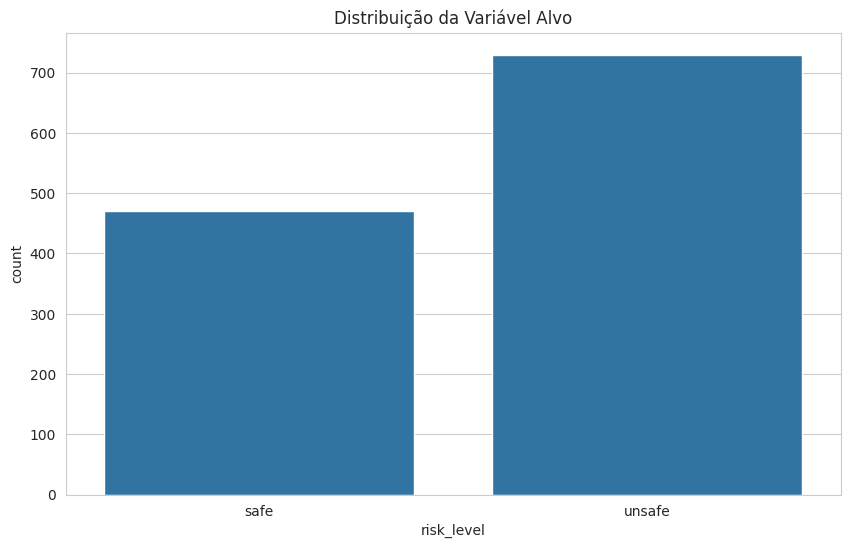

In [ ]:

# ======================================================
# DISTRIBUIÇÃO DA VARIÁVEL ALVO
# ======================================================

# Contagem das classes da variável alvo
target_counts = df["risk_level"].value_counts()

print(target_counts)

sns.countplot(data=df, x="risk_level")
plt.title("Distribuição da Variável Alvo")
plt.show()


In [ ]:

# ======================================================
# ESTATÍSTICAS POR CLASSE
# ======================================================

# Comparação das médias das variáveis numéricas entre as classes
df.groupby("risk_level").mean(numeric_only=True).T


risk_level,safe,unsafe
record_id,602.917021,598.943836
temperature_c,44.417968,52.475119
distance_cm,106.542013,78.969020
vibration_mm_s,5.523073,6.445798
humidity_pct,51.662252,52.468398
pressure_bar,6.615213,6.512274
noise_db,79.459066,81.506661
runtime_min,137.430638,144.668493
operator_fatigue_score,4.927093,5.670423
near_miss_last_30d,0.963830,1.312329


In [ ]:

# ======================================================
# VERIFICAÇÃO DE VALORES NULOS
# ======================================================

# Identificação de valores faltantes no dataset
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]


,0
humidity_pct,48
temperature_c,36
operator_fatigue_score,36
distance_cm,24
maintenance_status,24
ppe_compliance,18


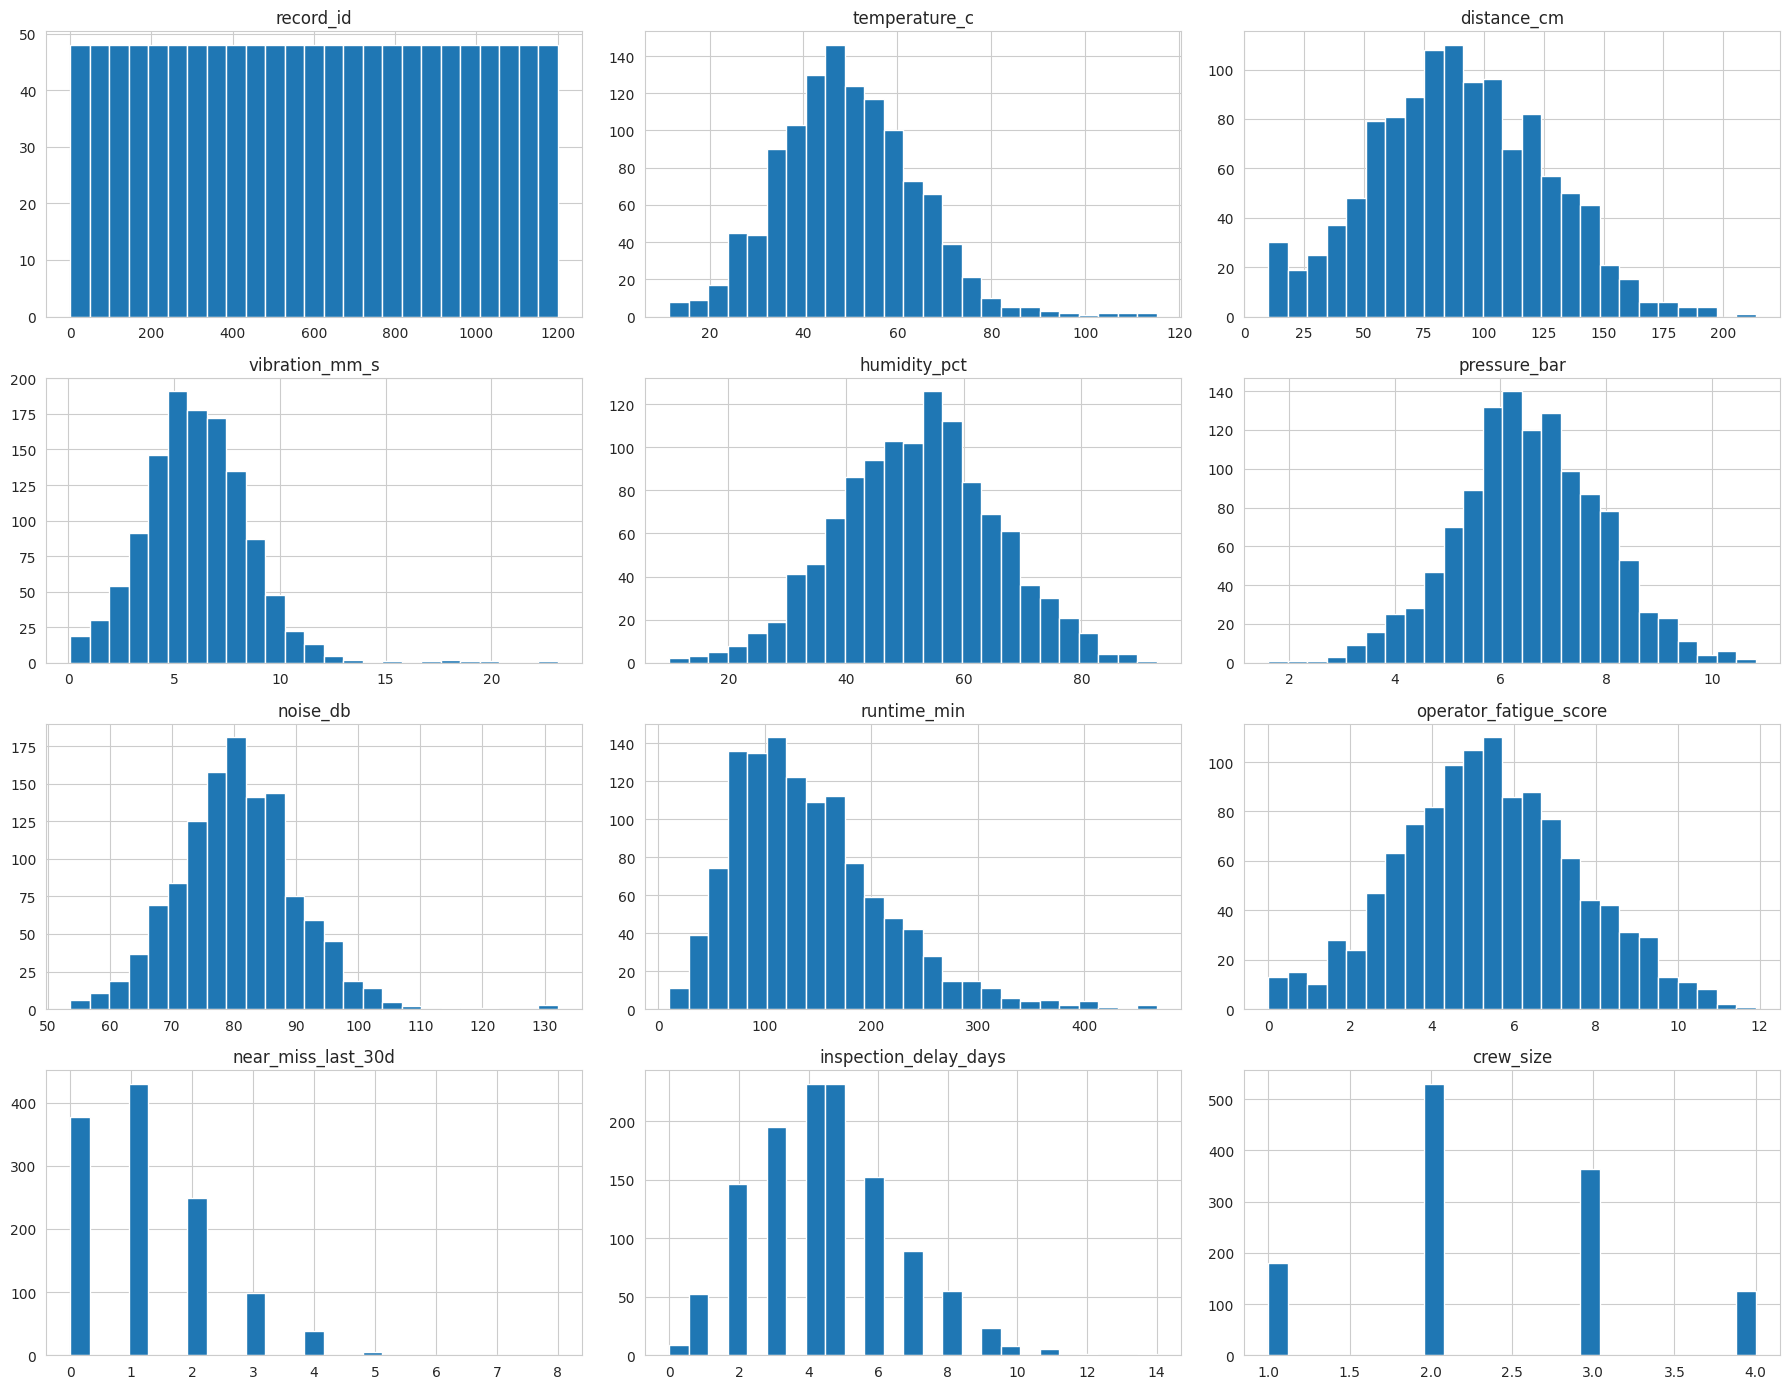

In [ ]:

# ======================================================
# DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS
# ======================================================

# Seleção das variáveis numéricas para análise estatística e visual
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(figsize=(18, 14), bins=25)

plt.tight_layout()
plt.show()


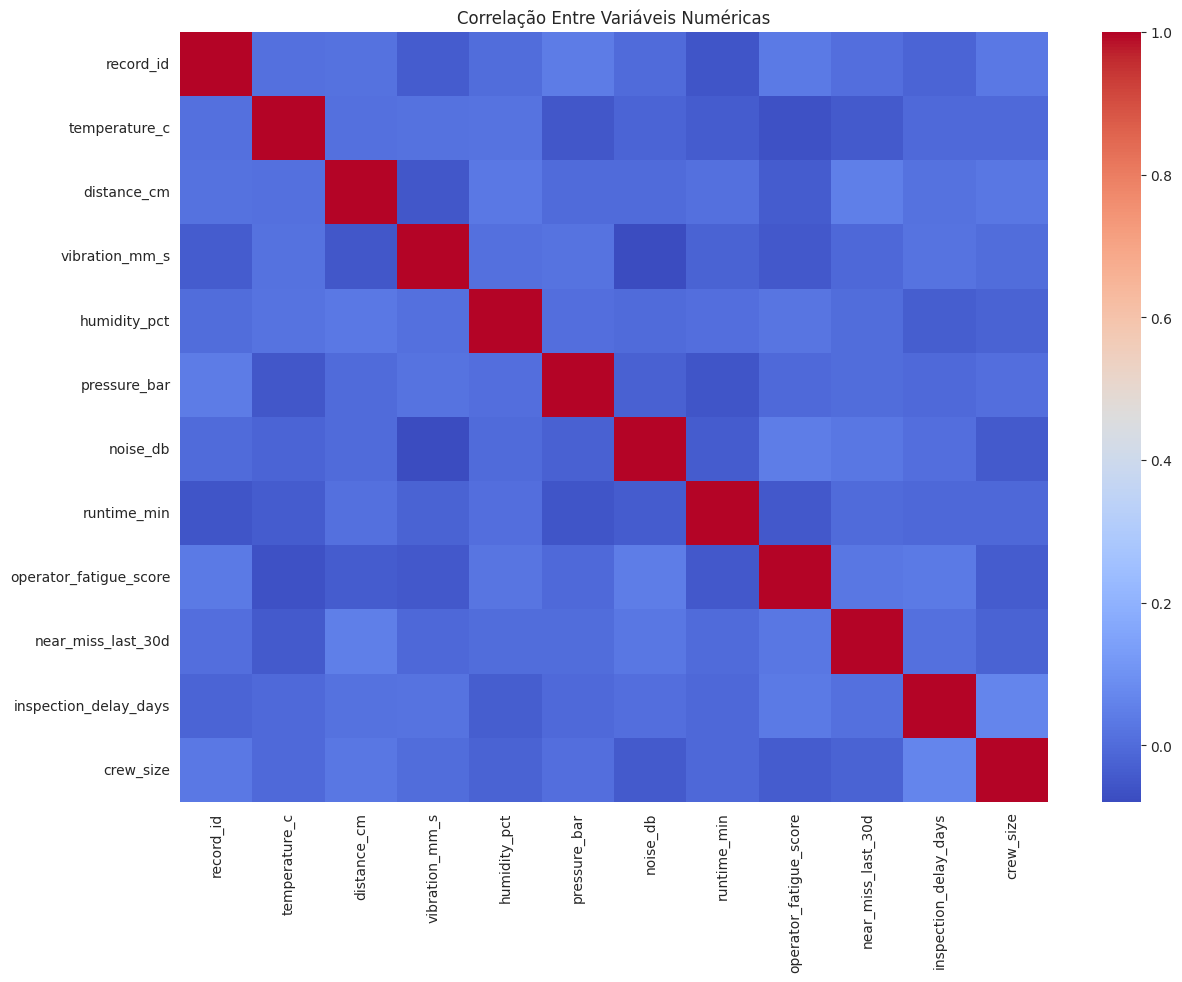

In [ ]:

# ======================================================
# MATRIZ DE CORRELAÇÃO
# ======================================================

# Cálculo da matriz de correlação entre variáveis numéricas
corr = df[numeric_cols].corr()

plt.figure(figsize=(14,10))

sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("Correlação Entre Variáveis Numéricas")
plt.show()


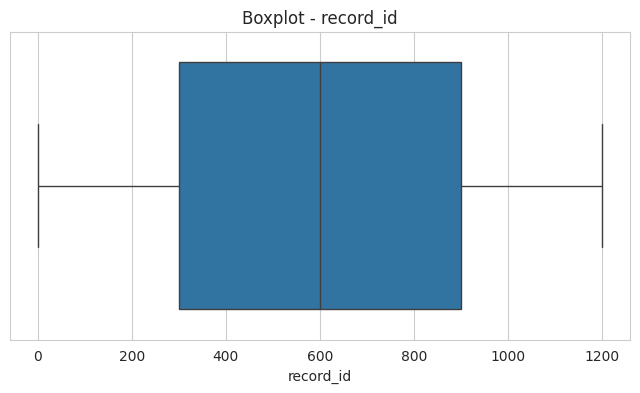

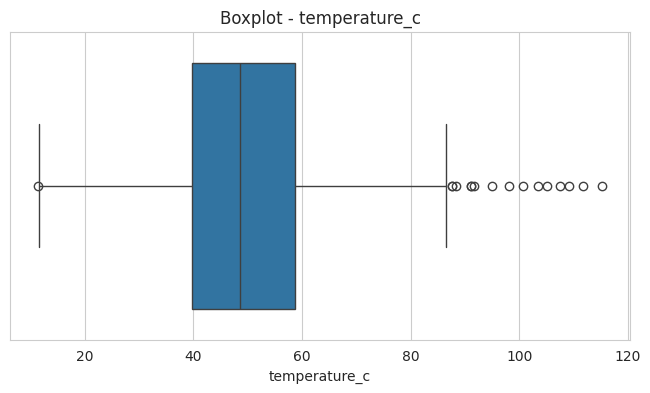

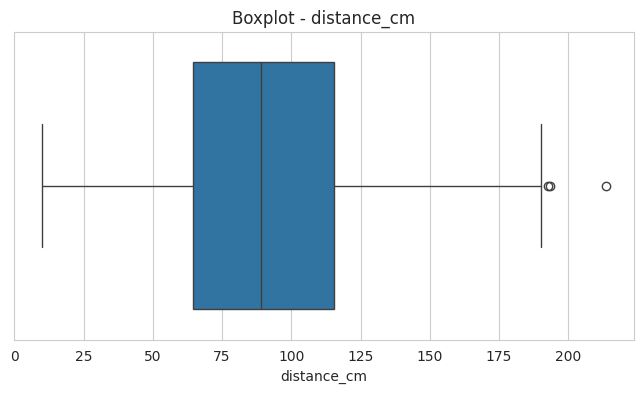

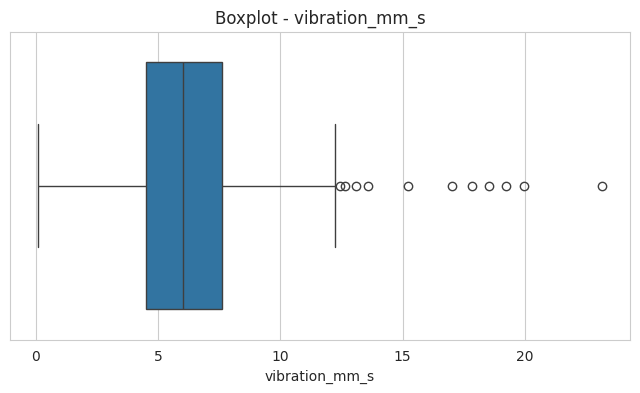

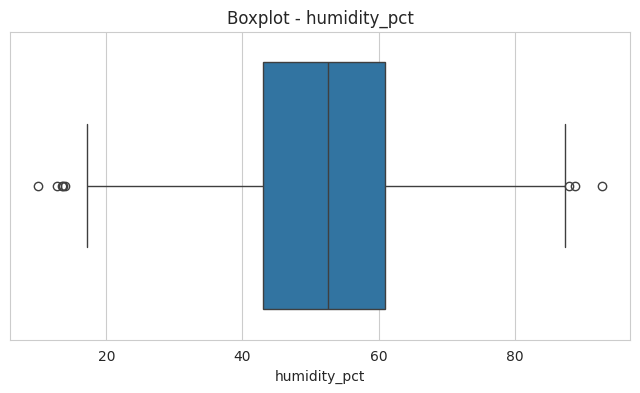

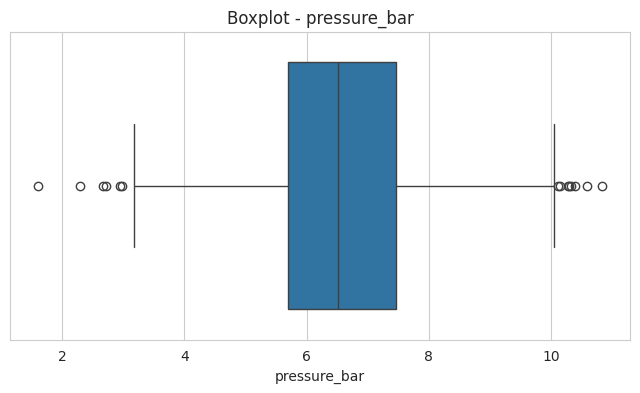

In [ ]:

# ======================================================
# ANÁLISE DE OUTLIERS
# ======================================================

# Visualização de possíveis outliers através de boxplots
for col in numeric_cols[:6]:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()


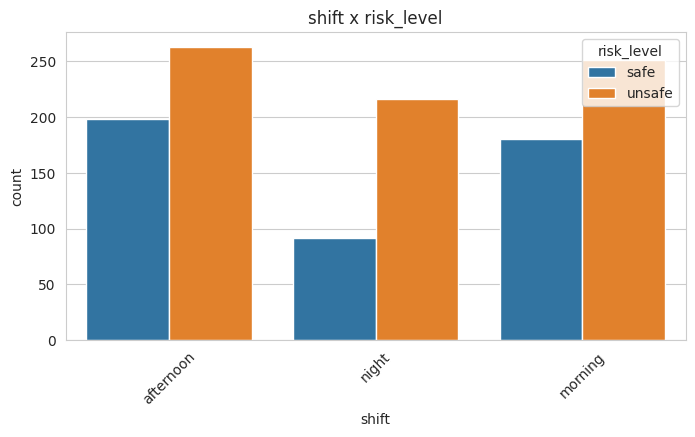

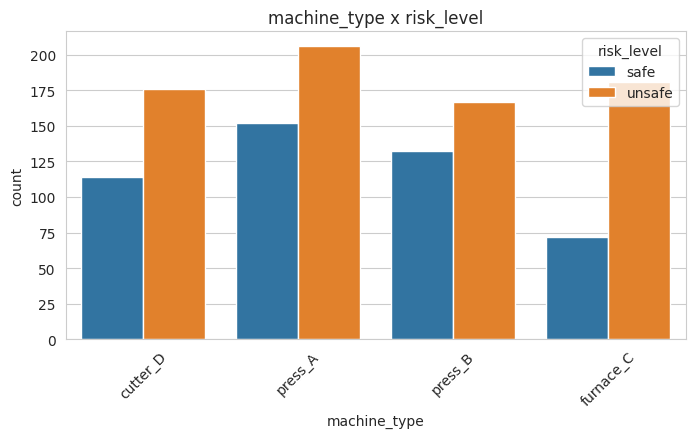

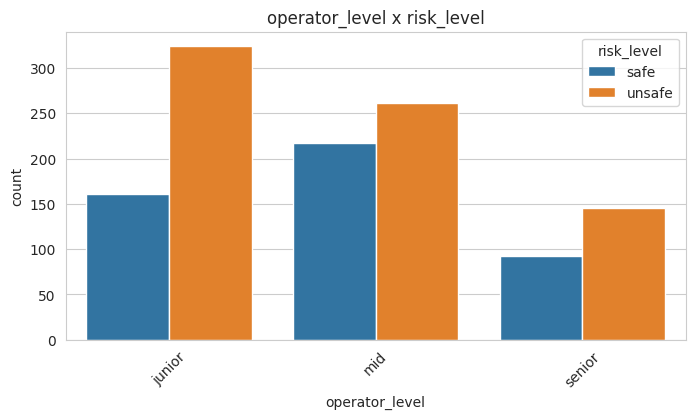

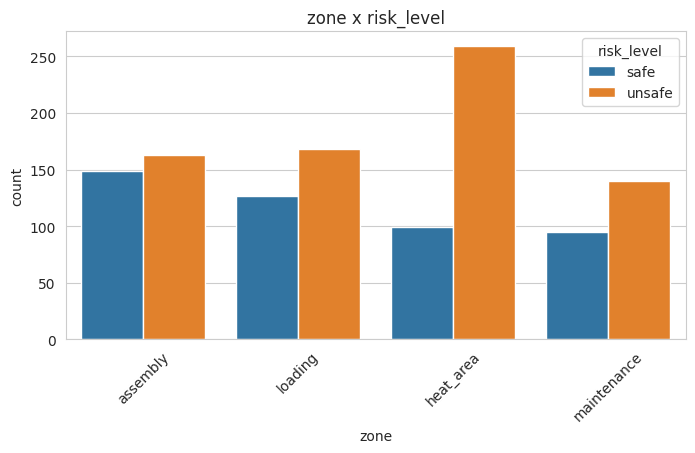

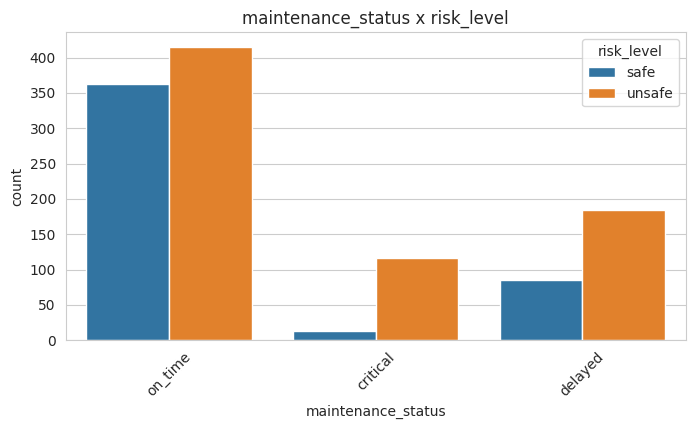

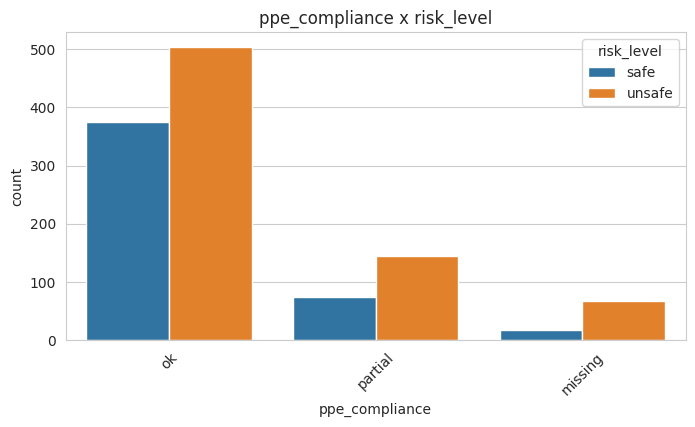

In [ ]:

# ======================================================
# ANÁLISE DAS VARIÁVEIS CATEGÓRICAS
# ======================================================

# Seleção das variáveis categóricas para análise de distribuição
categorical_cols = df.select_dtypes(include="object").columns.drop("risk_level")

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue="risk_level")
    plt.xticks(rotation=45)
    plt.title(f"{col} x risk_level")
    plt.show()



# 2. DATA CLEANING E PRÉ-PROCESSAMENTO

## Objetivo desta etapa

Nesta fase será realizado o tratamento dos dados para preparação dos modelos de Machine Learning.

As principais atividades incluem:
- tratamento de valores faltantes;
- aplicação de técnicas de normalização;
- codificação de variáveis categóricas;
- separação entre treino e teste utilizando Holdout;
- construção de pipelines robustos para evitar inconsistências no treinamento.

O objetivo é garantir maior qualidade, padronização e confiabilidade para os algoritmos.

In [ ]:

# ======================================================
# REMOÇÃO DE COLUNAS IRRELEVANTES
# ======================================================

# record_id não agrega valor preditivo

# Remoção de coluna identificadora sem relevância preditiva

df = df.drop(columns=["record_id"])


In [ ]:

# ======================================================
# ENCODING DA VARIÁVEL TARGET
# ======================================================

# Conversão da variável alvo para formato numérico
df["risk_level"] = df["risk_level"].map({
    "safe": 0,
    "unsafe": 1
})

df["risk_level"].value_counts()


,count
risk_level,
1,730
0,470


### Engenharia de Features

Nesta etapa são criadas novas variáveis derivadas com o objetivo de enriquecer o poder preditivo do modelo.

As features geradas procuram representar:
- risco ambiental;
- estresse operacional;
- relações entre sensores industriais.

A criação dessas variáveis busca capturar relações não lineares presentes no ambiente industrial.

In [ ]:
# ======================================================
# FEATURE ENGINEERING
# ======================================================

# 1. Índice de Estresse do Operador (Fadiga + Ruído)
df['stress_index'] = df['operator_fatigue_score'] * (df['noise_db'] / 100)

# 2. Risco Ambiental (Temperatura + Humidade)
df['env_risk_score'] = (df['temperature_c'] / 100) * (df['humidity_pct'] / 100)

# 3. Proximidade Crítica (Distância baixa + Vibração alta)
df['proximity_vibration_ratio'] = df['vibration_mm_s'] / (df['distance_cm'] + 1)

print("Novas features criadas: stress_index, env_risk_score, proximity_vibration_ratio")


In [ ]:

# ======================================================
# SEPARAÇÃO ENTRE FEATURES E TARGET
# ======================================================

# Separação entre variáveis preditoras e variável alvo
X = df.drop("risk_level", axis=1)
y = df["risk_level"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numéricas:", numeric_features)
print("\nCategóricas:", categorical_features)


Numéricas: ['temperature_c', 'distance_cm', 'vibration_mm_s', 'humidity_pct', 'pressure_bar', 'noise_db', 'runtime_min', 'operator_fatigue_score', 'near_miss_last_30d', 'inspection_delay_days', 'crew_size']

Categóricas: ['shift', 'machine_type', 'operator_level', 'zone', 'maintenance_status', 'ppe_compliance']


In [ ]:

# ======================================================
# HOLDOUT - DIVISÃO TREINO/TESTE
# ======================================================

# Divisão Holdout entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)


Treino: (960, 17)
Teste: (240, 17)


### Construção do Pipeline de Pré-processamento

O uso de *Pipeline* e *ColumnTransformer* garante:
- padronização do fluxo de dados;
- redução de risco de data leakage;
- maior reprodutibilidade do projeto;
- integração eficiente entre transformação e modelagem.

In [ ]:

# ======================================================
# PIPELINE DE PRÉ-PROCESSAMENTO
# ======================================================

# Pipeline de transformação das variáveis numéricas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline de transformação das variáveis categóricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# União dos pipelines em um único pré-processador
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['temperature_c', 'distance_cm',
                                  'vibration_mm_s', 'humidity_pct',
                                  'pressure_bar', 'noise_db', 'runtime_min',
                                  'operator_fatigue_score',
                                  'near_miss_last_30d', 'inspection_delay_days',
                                  'crew_size']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['shift', 'machine_type', 'operator_level',
                                  'zone', 'maintenance_status',
                                  'ppe_compliance'])])

In [ ]:
# ======================================================
# FEATURE ENGINEERING
# ======================================================

# Criação de variáveis derivadas para capturar relações
# operacionais e humanas mais complexas

if "temperature" in df.columns and "humidity" in df.columns:
    df["temp_humidity_interaction"] = (
        df["temperature"] * df["humidity"]
    )

if "worker_fatigue" in df.columns and "shift_duration" in df.columns:
    df["fatigue_shift_ratio"] = (
        df["worker_fatigue"] / (df["shift_duration"] + 1)
    )


# 3. MODELAGEM

## Objetivo desta etapa

Nesta seção serão treinados e comparados diferentes algoritmos de classificação supervisionada.

Os modelos escolhidos incluem:
- modelos lineares;
- árvores de decisão;
- métodos ensemble e gradient boosting.

A intenção é comparar desempenho, robustez e capacidade preditiva entre abordagens simples e avançadas.

### Estratégia de Modelagem

Os modelos foram selecionados para permitir comparação entre:
- algoritmos lineares;
- modelos baseados em árvore;
- ensembles avançados.

Essa abordagem permite avaliar diferenças de capacidade preditiva, interpretabilidade e robustez.

In [ ]:

# ======================================================
# DEFINIÇÃO DOS MODELOS
# ======================================================

# Definição dos modelos que serão comparados durante o treinamento
models = {

    "Logistic Regression": LogisticRegression(max_iter=2000),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        verbose=0,
        random_state=42
    )
}

models


{'Logistic Regression': LogisticRegression(max_iter=2000),
 'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
 'Random Forest': RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42),
 'LightGBM': LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
      

### Otimização de Hiperparâmetros

Nesta etapa é aplicada validação cruzada com busca de hiperparâmetros.

O objetivo é:
- melhorar a generalização;
- reduzir overfitting;
- encontrar configurações mais eficientes para os modelos ensemble.

In [ ]:
# ======================================================
# OTIMIZAÇÃO DE HIPERPARAMETROS E VALIDAÇÃO CRUZADA
# ======================================================

from sklearn.model_selection import RandomizedSearchCV

# Exemplo com Random Forest para demonstrar a técnica
rf_params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_rf = RandomizedSearchCV(
    pipeline_rf, rf_params, n_iter=5, cv=cv,
    scoring='roc_auc', n_jobs=-1, random_state=42
)

random_search_rf.fit(X_train, y_train)
print(f"Melhor ROC AUC (RF) via CV: {random_search_rf.best_score_:.4f}")
best_rf = random_search_rf.best_estimator_


In [ ]:
# ======================================================
# INTERPRETABILIDADE: IMPORTÂNCIA DAS VARIÁVEIS
# ======================================================

# Extraindo importâncias do Random Forest otimizado
importances = best_rf.named_steps['classifier'].feature_importances_
feature_names = (best_rf.named_steps['preprocessor']
                .transformers_[1][1]
                .named_steps['onehot']
                .get_feature_names_out(categorical_features).tolist() + numeric_features)

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp.head(15), y=feat_imp.head(15).index)
plt.title("Top 15 Variáveis Mais Importantes (Random Forest)")
plt.show()


In [ ]:

# ======================================================
# TREINAMENTO E AVALIAÇÃO
# ======================================================

# Estruturas para armazenamento das métricas e modelos treinados
results = []

trained_models = {}

# Loop responsável pelo treinamento e avaliação de cada modelo
for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    }

    results.append(metrics)

    trained_models[name] = pipeline

    print("="*60)
    print(name)
    print("="*60)

    print(classification_report(y_test, y_pred))

# Consolidação das métricas em um DataFrame comparativo
results_df = pd.DataFrame(results)

results_df.sort_values(by="ROC AUC", ascending=False)


Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.71      0.76        94
           1       0.83      0.90      0.86       146

    accuracy                           0.82       240
   macro avg       0.82      0.81      0.81       240
weighted avg       0.82      0.82      0.82       240

Decision Tree
              precision    recall  f1-score   support

           0       0.64      0.77      0.70        94
           1       0.83      0.73      0.77       146

    accuracy                           0.74       240
   macro avg       0.74      0.75      0.74       240
weighted avg       0.76      0.74      0.74       240

Random Forest
              precision    recall  f1-score   support

           0       0.81      0.63      0.71        94
           1       0.79      0.90      0.84       146

    accuracy                           0.80       240
   macro avg       0.80      0.77      0.78       240
weighted avg       0.80   

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.825000,0.829114,0.897260,0.861842,0.906368
2,Random Forest,0.795833,0.790419,0.904110,0.843450,0.883707
5,CatBoost,0.800000,0.802469,0.890411,0.844156,0.881886
4,XGBoost,0.808333,0.824675,0.869863,0.846667,0.869717
3,LightGBM,0.787500,0.806452,0.856164,0.830565,0.865273
1,Decision Tree,0.741667,0.828125,0.726027,0.773723,0.810879



# 4. COMPARAÇÃO DOS MODELOS

## Objetivo desta etapa

Após o treinamento dos modelos, será realizada uma análise comparativa utilizando métricas de classificação.

Serão avaliados:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC AUC

Essa comparação permitirá identificar o modelo mais adequado para o contexto industrial da SafeForge.

In [ ]:

# ======================================================
# TABELA COMPARATIVA
# ======================================================

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.825000,0.829114,0.897260,0.861842,0.906368
1,Random Forest,0.795833,0.790419,0.904110,0.843450,0.883707
2,CatBoost,0.800000,0.802469,0.890411,0.844156,0.881886
3,XGBoost,0.808333,0.824675,0.869863,0.846667,0.869717
4,LightGBM,0.787500,0.806452,0.856164,0.830565,0.865273
5,Decision Tree,0.741667,0.828125,0.726027,0.773723,0.810879


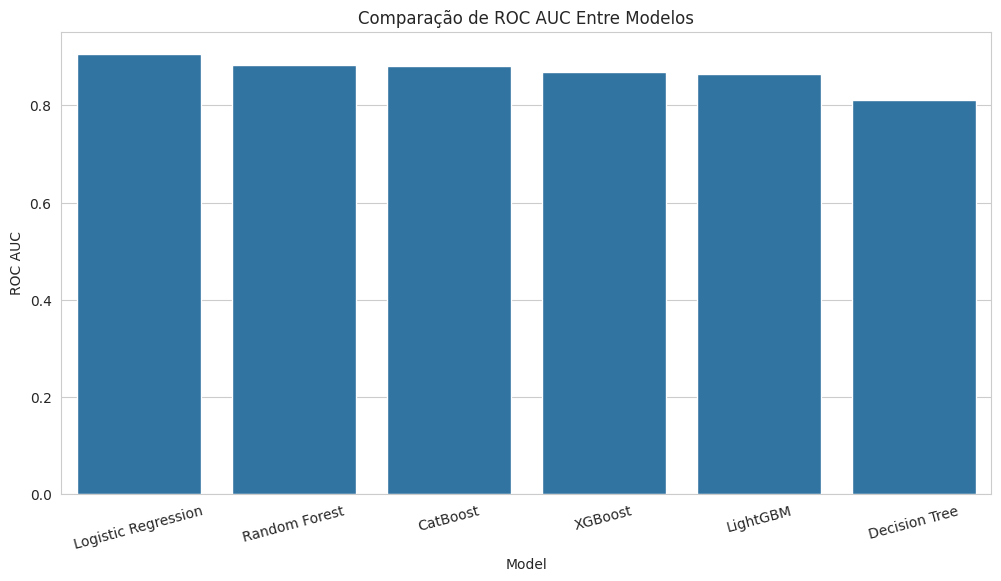

In [ ]:

# ======================================================
# COMPARAÇÃO VISUAL - ROC AUC
# ======================================================

# Comparação visual do desempenho dos modelos utilizando ROC AUC
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC AUC"
)

plt.title("Comparação de ROC AUC Entre Modelos")
plt.xticks(rotation=15)

plt.show()


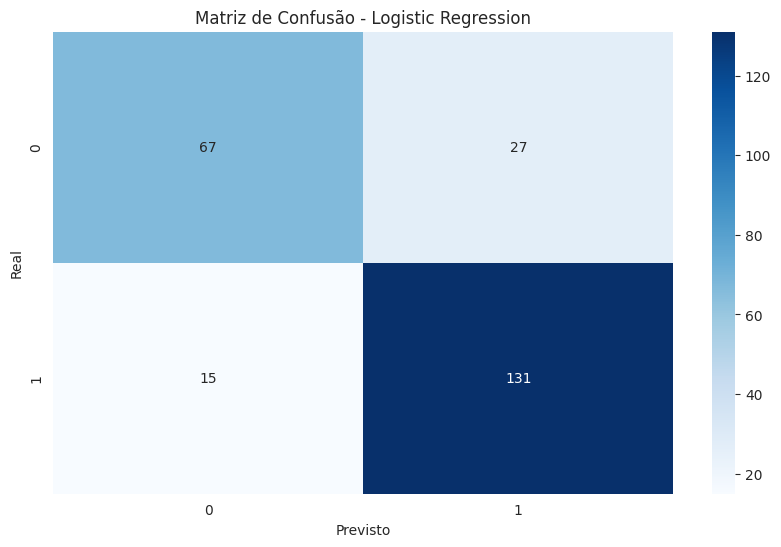

Melhor modelo: Logistic Regression


In [ ]:

# ======================================================
# MATRIZ DE CONFUSÃO DO MELHOR MODELO
# ======================================================

# Seleção automática do modelo com melhor desempenho
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title(f"Matriz de Confusão - {best_model_name}")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

print("Melhor modelo:", best_model_name)



# 5. INTERPRETAÇÃO DOS RESULTADOS

## Objetivo desta etapa

Nesta fase será feita a interpretação dos resultados obtidos pelos modelos.

O foco será:
- identificar as variáveis mais importantes;
- analisar os fatores que mais influenciam o risco operacional;
- traduzir os resultados técnicos para o contexto de negócio da SafeForge.

Essa interpretação é essencial para transformar previsões em decisões estratégicas.

### Interpretação das Variáveis Mais Relevantes

A análise de importância das features permite identificar:
- quais fatores mais impactam o risco operacional;
- quais variáveis possuem maior influência nas previsões;
- como os resultados podem auxiliar tomadas de decisão industriais.

In [ ]:

# ======================================================
# FEATURE IMPORTANCE
# ======================================================

# Modelos ensemble geralmente entregam melhores importâncias

# Modelos baseados em árvores utilizados para análise de importância das variáveis

tree_models = [
    "Random Forest",
    "LightGBM",
    "XGBoost",
    "CatBoost"
]

selected_model_name = best_model_name

model_pipeline = trained_models[selected_model_name]

# Recuperando nomes das colunas após encoding

ohe = model_pipeline.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["onehot"]

encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_features = numeric_features + list(encoded_cat_features)

model = model_pipeline.named_steps["model"]

if hasattr(model, "feature_importances_"):

    # Organização das variáveis mais relevantes para o modelo

    importances = pd.DataFrame({
        "Feature": all_features,
        "Importance": model.feature_importances_
    })

    importances = importances.sort_values(
        by="Importance",
        ascending=False
    ).head(15)

    plt.figure(figsize=(12,7))

    sns.barplot(
        data=importances,
        x="Importance",
        y="Feature"
    )

    plt.title(f"Top 15 Variáveis Mais Importantes - {selected_model_name}")

    plt.show()

    importances



# Conclusão Final

## Principais Insights

Durante a análise exploratória, foi possível observar:

- presença de relações não lineares
- influência de variáveis operacionais e humanas
- impacto significativo de fadiga, vibração, ruído e atrasos de inspeção

---

## Comparação dos Modelos

Os modelos ensemble apresentaram desempenho superior aos modelos lineares e árvores simples.

### Motivos:
- maior capacidade de capturar relações complexas
- melhor tratamento de interações entre variáveis
- redução de overfitting

---

## Melhor Modelo

O melhor modelo foi selecionado com base principalmente em:

- ROC AUC
- F1-Score
- Recall

Essas métricas são fundamentais em cenários industriais, pois minimizar falsos negativos é extremamente importante para evitar acidentes.

---

## Aplicação no Contexto da SafeForge

A solução desenvolvida pode auxiliar a SafeForge em:

- monitoramento preventivo
- identificação de ambientes inseguros
- apoio à tomada de decisão
- redução de acidentes operacionais
- priorização de inspeções e manutenção

---

## Considerações Técnicas

Este pipeline implementa:

- EDA completa
- tratamento de dados
- pipeline profissional
- modelos avançados
- avaliação robusta
- interpretação de resultados

A estrutura segue boas práticas de Machine Learning aplicadas em ambientes corporativos e industriais.
